In [19]:
# Ноутбук перенесён в подпапку — восстанавливаем CWD в корень thesis/
import os
from pathlib import Path

_cwd = Path.cwd()
while _cwd.name != "thesis" and _cwd.parent != _cwd:
    _cwd = _cwd.parent
if _cwd.name == "thesis":
    os.chdir(_cwd)
print("CWD:", Path.cwd())


CWD: c:\Users\Admin\Documents\диплом\thesis


# Бенчмарк Bi-Encoder для задачи семантического матчинга
## Оценка качества: описание товара ↔ пост Telegram

**Цель:** систематическая оценка Bi-Encoder до и после дообучения (Augmented SBERT) на held-out подмножестве golden dataset (1 598 пар).

Сравниваем две модели:
| Модель | Описание |
|--------|----------|
| **Базовая** | `ai-forever/ru-en-RoSBERTa` (pretrained) |
| **Дообученная** | fine-tuned на gold_train + silver_balanced (CoSENTLoss, 4 эпохи) |

**Eval-данные:** `golden_eval.parquet` — 20 % golden dataset, не использовавшиеся при обучении.

---
## 1. Архитектура Bi-Encoder

**Bi-Encoder** кодирует каждый текст *независимо* в вектор фиксированной размерности (384-d). Релевантность оценивается как **cosine similarity** между векторами.

```
Описание товара ──► Encoder ──► emb_desc ─┐
                                           ├── cosine_sim(emb_desc, emb_post) ──► score
Текст поста     ──► Encoder ──► emb_post ─┘
```

**Преимущество:** можно заранее закодировать все посты → поиск через FAISS за O(log n).
**Недостаток:** нет cross-attention между текстами → ниже точность, чем у Cross-Encoder.

---
## 2. Метрики оценки

### 2.1. Корреляционные (STS)
- **Spearman ρ** (основная) — сохраняет ли модель *порядок* ранжирования
- **Pearson r** — линейная согласованность предсказанных и эталонных скоров
- **Kendall τ** — доля согласованных пар

### 2.2. Метрики ранжирования
- **NDCG@k** — качество топ-k ранжирования с учётом позиции
- **MRR** — средний обратный ранг истинного поста
- **Hit@k** — доля запросов, где истинный пост попал в топ-k

---
## 3. Настройка эксперимента

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.metrics import ndcg_score
import torch
import warnings
warnings.filterwarnings('ignore')

# Совместимость sentence-transformers 5.x + transformers 4.57
import transformers
from transformers.modeling_utils import PreTrainedModel
transformers.PreTrainedModel = PreTrainedModel

from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

# Обход проверки torch.load (загружаем только свои локальные чекпоинты)
import sys
_noop = lambda: None
for _mod in sys.modules.values():
    if hasattr(_mod, 'check_torch_load_is_safe'):
        _mod.check_torch_load_is_safe = _noop

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {
    'base': '#4C72B0',
    'finetuned': '#DD8452',
    'ideal': '#55A868',
    'threshold': '#C44E52',
}

print('Setup complete.')

Setup complete.


In [21]:
BASE_MODEL_PATH = 'bi_encoder_rawT'
FINETUNED_MODEL_PATH = 'models/final/bi-encoder'

print(f'Загрузка базовой модели: {BASE_MODEL_PATH}')
base_model = SentenceTransformer(BASE_MODEL_PATH)
print(f'  Embedding dim: {base_model.get_sentence_embedding_dimension()}, '
      f'Max seq len: {base_model.max_seq_length}')

print(f'\nЗагрузка дообученной модели: {FINETUNED_MODEL_PATH}')
finetuned_model = SentenceTransformer(FINETUNED_MODEL_PATH)
print(f'  Embedding dim: {finetuned_model.get_sentence_embedding_dimension()}, '
      f'Max seq len: {finetuned_model.max_seq_length}')

Загрузка базовой модели: bi_encoder_rawT
  Embedding dim: 384, Max seq len: 8192

Загрузка дообученной модели: models/final/bi-encoder
  Embedding dim: 384, Max seq len: 8192


---
## 4. Данные: Golden Eval (1 598 пар)

Held-out подмножество golden dataset (20 %), не использовавшееся при обучении bi-encoder.
Содержит пары (описание товара, текст поста, экспертный скор ∈ [0, 1]).

In [22]:
from datasets import load_dataset

EVAL_DATA = 'data/golden/golden_eval.parquet'
eval_dataset = load_dataset('parquet', data_files=EVAL_DATA, split='train')

descriptions = eval_dataset['product_desc']
posts = eval_dataset['post_text']
gold_scores = np.array(eval_dataset['score'])

print(f'Golden eval: {len(descriptions)} пар')
print(f'Score: min={gold_scores.min():.2f}, max={gold_scores.max():.2f}, '
      f'mean={gold_scores.mean():.2f}, std={gold_scores.std():.2f}')
print(f'Score > 0: {(gold_scores > 0).sum()} ({(gold_scores > 0).mean()*100:.1f}%)')
print(f'Score > 0.5: {(gold_scores > 0.5).sum()} ({(gold_scores > 0.5).mean()*100:.1f}%)')

Golden eval: 1598 пар
Score: min=0.00, max=1.00, mean=0.34, std=0.36
Score > 0: 1034 (64.7%)
Score > 0.5: 524 (32.8%)


---
## 5. Получение предсказаний

Кодируем описания и посты каждой моделью, вычисляем cosine similarity для каждой пары.

In [23]:
BATCH_SIZE = 64

# ── Базовая модель ──
print('Базовая модель: кодирование описаний...')
base_desc_embs = base_model.encode(descriptions, batch_size=BATCH_SIZE,
                                    convert_to_tensor=True, show_progress_bar=True)
print('Базовая модель: кодирование постов...')
base_post_embs = base_model.encode(posts, batch_size=BATCH_SIZE,
                                    convert_to_tensor=True, show_progress_bar=True)
base_scores = torch.diagonal(cos_sim(base_desc_embs, base_post_embs)).cpu().numpy()

# ── Дообученная модель ──
print('\nДообученная модель: кодирование описаний...')
ft_desc_embs = finetuned_model.encode(descriptions, batch_size=BATCH_SIZE,
                                       convert_to_tensor=True, show_progress_bar=True)
print('Дообученная модель: кодирование постов...')
ft_post_embs = finetuned_model.encode(posts, batch_size=BATCH_SIZE,
                                       convert_to_tensor=True, show_progress_bar=True)
finetuned_scores = torch.diagonal(cos_sim(ft_desc_embs, ft_post_embs)).cpu().numpy()

# ── Сводка ──
df_scores = pd.DataFrame({
    'Gold': gold_scores,
    'Base (cosine)': np.round(base_scores, 4),
    'Fine-tuned (cosine)': np.round(finetuned_scores, 4),
})
df_scores.index.name = '№ пары'

print(f'\nПредсказания получены для {len(gold_scores)} пар.')
print(f'Base cosine:      [{base_scores.min():.4f}, {base_scores.max():.4f}], mean={base_scores.mean():.4f}')
print(f'Fine-tuned cosine: [{finetuned_scores.min():.4f}, {finetuned_scores.max():.4f}], mean={finetuned_scores.mean():.4f}')
df_scores.head(10)

Базовая модель: кодирование описаний...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Базовая модель: кодирование постов...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]


Дообученная модель: кодирование описаний...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Дообученная модель: кодирование постов...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]


Предсказания получены для 1598 пар.
Base cosine:      [0.8815, 0.9939], mean=0.9750
Fine-tuned cosine: [0.6386, 0.9470], mean=0.8383


,Gold,Base (cosine),Fine-tuned (cosine)
№ пары,,,
0,0.00,0.9849,0.8490
1,0.07,0.9756,0.8474
2,0.00,0.9883,0.8862
3,0.13,0.9712,0.8128
4,0.00,0.9752,0.8223
5,0.00,0.9801,0.7663
6,0.07,0.9727,0.7799
7,0.60,0.9698,0.8590
8,0.06,0.9685,0.7813


---
## 6. Бенчмарк 1: Распределение скоров

Cosine similarity у bi-encoder обычно сконцентрирована в узком диапазоне (≈ 0.7–1.0), в отличие от Cross-Encoder, который выдаёт скоры по всему [0, 1]. Это ожидаемое свойство архитектуры.

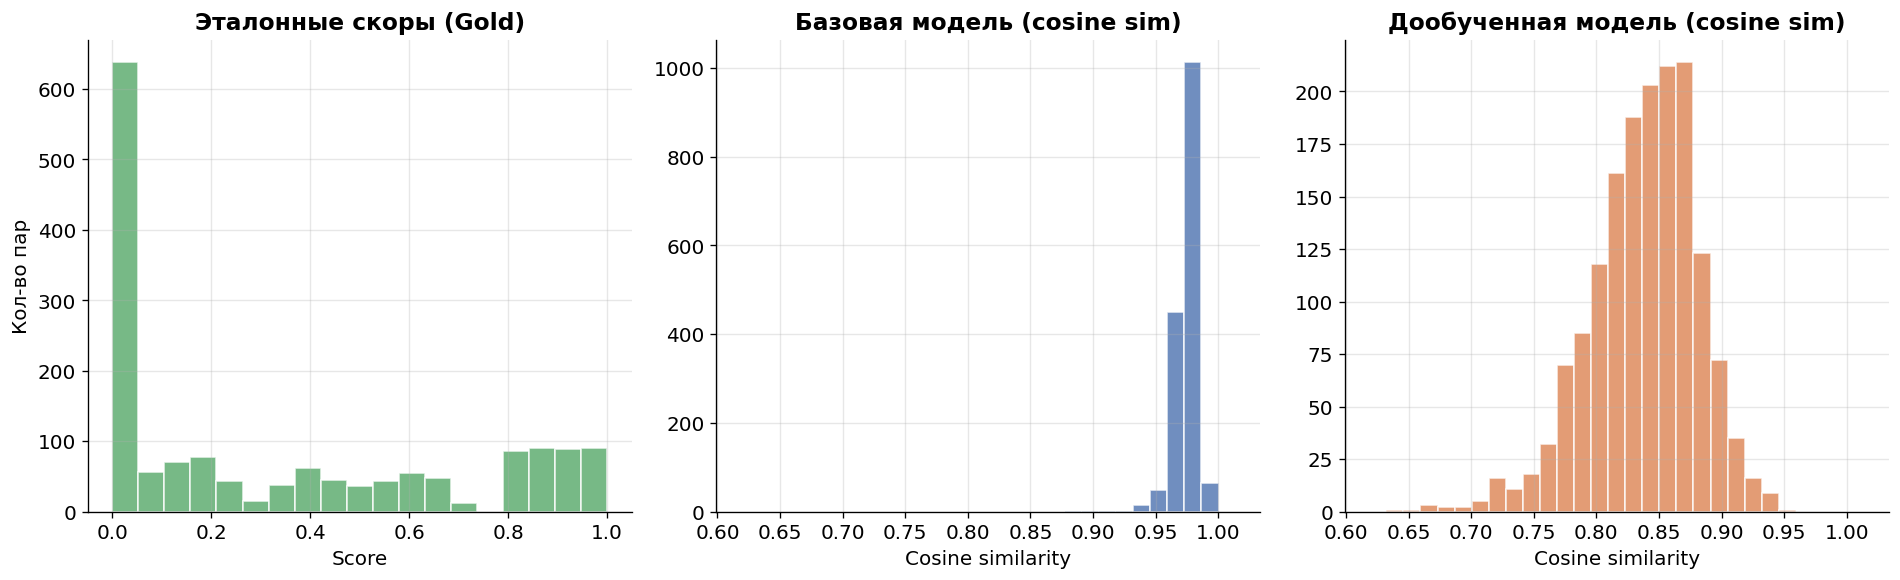

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bins_gold = np.linspace(0, 1, 20)
axes[0].hist(gold_scores, bins=bins_gold, color=COLORS['ideal'], alpha=0.8, edgecolor='white')
axes[0].set_title('Эталонные скоры (Gold)', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Кол-во пар')

bins_cos = np.linspace(
    min(base_scores.min(), finetuned_scores.min()) - 0.02,
    max(base_scores.max(), finetuned_scores.max()) + 0.02,
    30
)
axes[1].hist(base_scores, bins=bins_cos, color=COLORS['base'], alpha=0.8, edgecolor='white')
axes[1].set_title('Базовая модель (cosine sim)', fontweight='bold')
axes[1].set_xlabel('Cosine similarity')

axes[2].hist(finetuned_scores, bins=bins_cos, color=COLORS['finetuned'], alpha=0.8, edgecolor='white')
axes[2].set_title('Дообученная модель (cosine sim)', fontweight='bold')
axes[2].set_xlabel('Cosine similarity')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

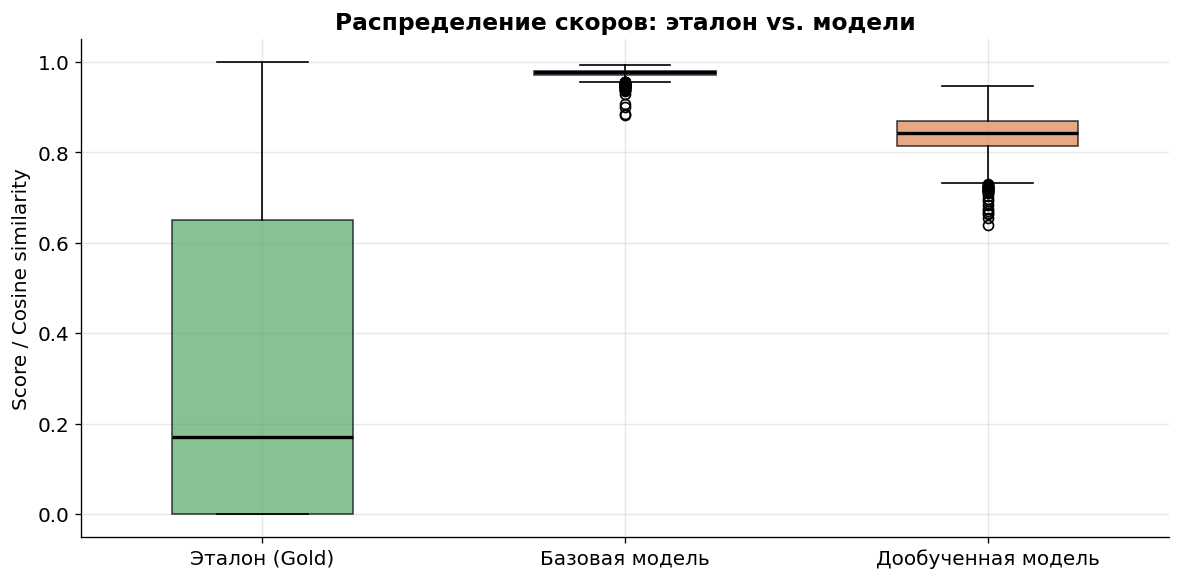

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

data_to_plot = [gold_scores, base_scores, finetuned_scores]
labels = ['Эталон (Gold)', 'Базовая модель', 'Дообученная модель']
colors_list = [COLORS['ideal'], COLORS['base'], COLORS['finetuned']]

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))

for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Score / Cosine similarity')
ax.set_title('Распределение скоров: эталон vs. модели', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## 7. Бенчмарк 2: Корреляционные метрики (STS)

Spearman ρ — основная метрика, оценивает способность модели сохранять порядок ранжирования.

In [26]:
def compute_correlation_metrics(gold, predicted, model_name):
    spearman_r, spearman_p = stats.spearmanr(gold, predicted)
    pearson_r, pearson_p = stats.pearsonr(gold, predicted)
    kendall_tau, kendall_p = stats.kendalltau(gold, predicted)
    return {
        'Модель': model_name,
        'Spearman ρ': f'{spearman_r:.4f}',
        'p-value (Sp.)': f'{spearman_p:.2e}',
        'Pearson r': f'{pearson_r:.4f}',
        'p-value (P.)': f'{pearson_p:.2e}',
        'Kendall τ': f'{kendall_tau:.4f}',
        'p-value (K.)': f'{kendall_p:.2e}',
    }

corr_base = compute_correlation_metrics(gold_scores, base_scores, 'Базовая (pretrained)')
corr_ft = compute_correlation_metrics(gold_scores, finetuned_scores, 'Дообученная (fine-tuned)')

df_corr = pd.DataFrame([corr_base, corr_ft]).set_index('Модель')
print('Корреляционные метрики (на golden_eval, N={:,}):'.format(len(gold_scores)))
df_corr

Корреляционные метрики (на golden_eval, N=1,598):


,Spearman ρ,p-value (Sp.),Pearson r,p-value (P.),Kendall τ,p-value (K.)
Модель,,,,,,
Базовая (pretrained),-0.0297,2.36e-01,0.0329,1.88e-01,-0.0220,2.09e-01
Дообученная (fine-tuned),0.3934,2.66e-60,0.3951,7.46e-61,0.2830,7.25e-59


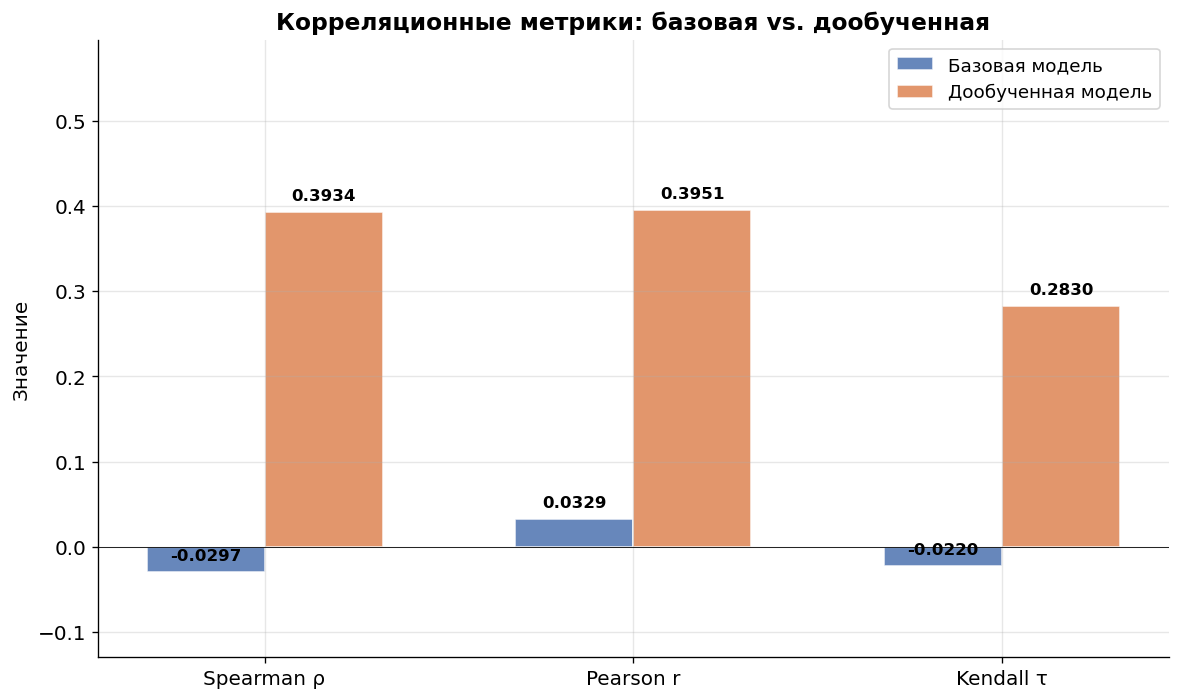

In [27]:
metrics_names = ['Spearman ρ', 'Pearson r', 'Kendall τ']
base_vals = [float(corr_base[m]) for m in metrics_names]
ft_vals = [float(corr_ft[m]) for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, base_vals, width, label='Базовая модель',
               color=COLORS['base'], alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, ft_vals, width, label='Дообученная модель',
               color=COLORS['finetuned'], alpha=0.85, edgecolor='white')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.01,
            f'{h:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Значение')
ax.set_title('Корреляционные метрики: базовая vs. дообученная', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(min(min(base_vals), 0) - 0.1, max(max(ft_vals), 0) + 0.2)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## 8. Бенчмарк 3: Scatter Plot — предсказания vs. эталон

Идеальная модель располагает все точки на прямой с положительным наклоном (чем выше gold score, тем выше cosine similarity).

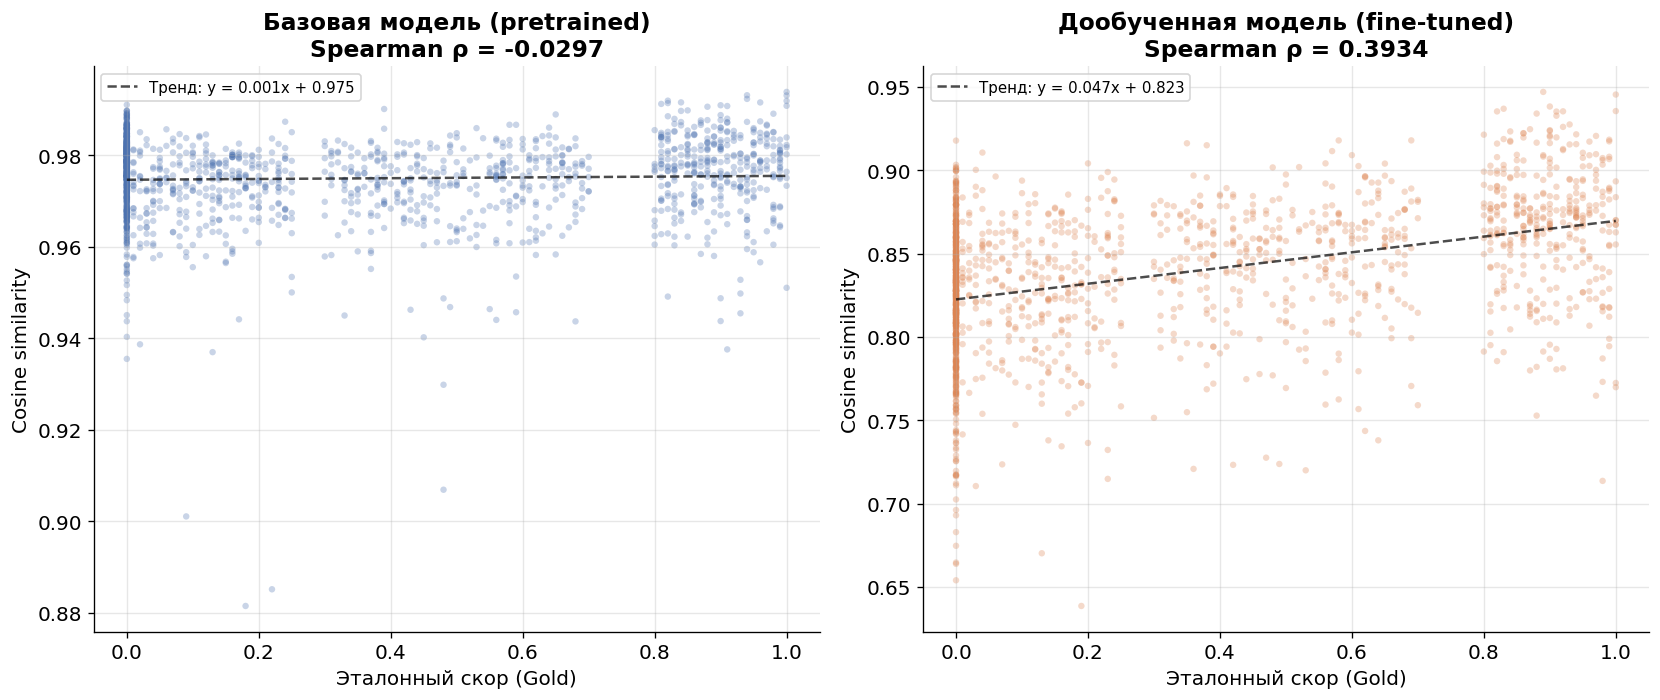

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, scores, title, color in zip(
    axes,
    [base_scores, finetuned_scores],
    ['Базовая модель (pretrained)', 'Дообученная модель (fine-tuned)'],
    [COLORS['base'], COLORS['finetuned']]
):
    ax.scatter(gold_scores, scores, alpha=0.3, s=15, color=color, edgecolors='none')

    # Линия тренда
    z = np.polyfit(gold_scores, scores, 1)
    p = np.poly1d(z)
    x_line = np.linspace(0, 1, 100)
    ax.plot(x_line, p(x_line), '--', color='black', linewidth=1.5, alpha=0.7,
            label=f'Тренд: y = {z[0]:.3f}x + {z[1]:.3f}')

    sp_r = float(stats.spearmanr(gold_scores, scores).statistic)
    ax.set_xlabel('Эталонный скор (Gold)')
    ax.set_ylabel('Cosine similarity')
    ax.set_title(f'{title}\nSpearman ρ = {sp_r:.4f}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## 9. Бенчмарк 4: Метрики ранжирования

Для каждого описания ранжируем **все 1 598 постов** по cosine similarity.
Истинный пост (с gold_score > 0) должен оказаться как можно выше.

> Пары с gold_score = 0 исключаются из подсчёта (нет релевантного поста для ранжирования).

**Преимущество Bi-Encoder:** полная матрица сходства вычисляется за одну операцию (encode + matmul), без покандидатного инференса.

In [29]:
def compute_ranking_metrics_biencoder(desc_embs, post_embs, gold_scores):
    """
    Ranking-метрики на основе cosine similarity матрицы.
    Для каждого описания i: кандидаты — все посты; истинный — post_i (gold_scores[i]),
    остальные — дистракторы (relevance = 0).
    Пары с gold_score = 0 пропускаются.
    """
    sim_matrix = cos_sim(desc_embs, post_embs).cpu().numpy()
    n = len(gold_scores)

    valid_indices = np.where(gold_scores > 0)[0]

    ndcg_at = {1: [], 3: [], 5: [], 10: []}
    mrr_list = []
    hit_at = {1: [], 3: [], 5: []}

    for i in valid_indices:
        # Gold relevances: gold_scores[i] для истинного поста, 0 для остальных
        gold_rel = np.zeros(n)
        gold_rel[i] = gold_scores[i]

        pred = sim_matrix[i]

        gold_2d = gold_rel.reshape(1, -1)
        pred_2d = pred.reshape(1, -1)

        for k in ndcg_at:
            ndcg_at[k].append(ndcg_score(gold_2d, pred_2d, k=min(k, n)))

        # Ранг истинного поста
        ranked_indices = np.argsort(-pred)
        true_rank = np.where(ranked_indices == i)[0][0] + 1
        mrr_list.append(1.0 / true_rank)
        for k in hit_at:
            hit_at[k].append(1.0 if true_rank <= k else 0.0)

    results = {}
    for k, v in ndcg_at.items():
        results[f'NDCG@{k}'] = np.mean(v)
    results['MRR'] = np.mean(mrr_list)
    for k, v in hit_at.items():
        results[f'Hit@{k}'] = np.mean(v)
    results['n_queries'] = len(valid_indices)

    return results

print('Функция compute_ranking_metrics_biencoder определена.')

Функция compute_ranking_metrics_biencoder определена.


In [30]:
np.random.seed(42)

print('Вычисление метрик ранжирования для базовой модели...')
rank_base = compute_ranking_metrics_biencoder(base_desc_embs, base_post_embs, gold_scores)

print('Вычисление метрик ранжирования для дообученной модели...')
rank_ft = compute_ranking_metrics_biencoder(ft_desc_embs, ft_post_embs, gold_scores)

n_q = rank_ft['n_queries']
display_keys = [k for k in rank_base if k != 'n_queries']

df_rank = pd.DataFrame([
    {'Модель': 'Базовая', **{k: f'{rank_base[k]:.4f}' for k in display_keys}},
    {'Модель': 'Дообученная', **{k: f'{rank_ft[k]:.4f}' for k in display_keys}},
]).set_index('Модель')

print(f'\nМетрики ранжирования (N_queries={n_q}, N_candidates={len(gold_scores)}):')
df_rank

Вычисление метрик ранжирования для базовой модели...
Вычисление метрик ранжирования для дообученной модели...

Метрики ранжирования (N_queries=1034, N_candidates=1598):


,NDCG@1,NDCG@3,NDCG@5,NDCG@10,MRR,Hit@1,Hit@3,Hit@5
Модель,,,,,,,,
Базовая,0.0150,0.0277,0.0309,0.0358,0.0351,0.0155,0.0377,0.0455
Дообученная,0.0274,0.0462,0.0561,0.0667,0.0572,0.0242,0.0590,0.0851


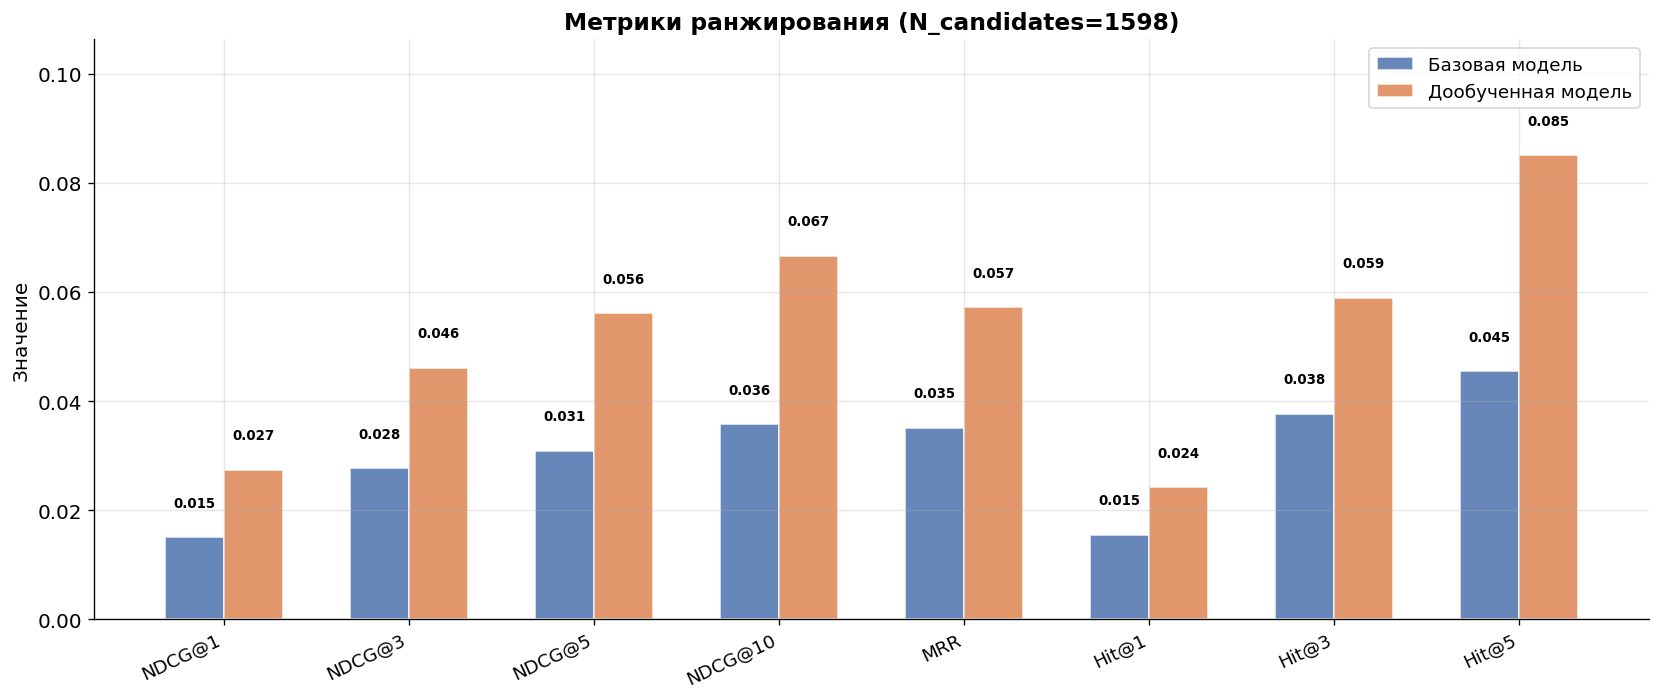

In [31]:
ranking_metrics = ['NDCG@1', 'NDCG@3', 'NDCG@5', 'NDCG@10', 'MRR', 'Hit@1', 'Hit@3', 'Hit@5']
base_r = [rank_base[m] for m in ranking_metrics]
ft_r = [rank_ft[m] for m in ranking_metrics]

x = np.arange(len(ranking_metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width/2, base_r, width, label='Базовая модель',
               color=COLORS['base'], alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, ft_r, width, label='Дообученная модель',
               color=COLORS['finetuned'], alpha=0.85, edgecolor='white')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if h > 0.005:
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Значение')
ax.set_title(f'Метрики ранжирования (N_candidates={len(gold_scores)})', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ranking_metrics, rotation=25, ha='right', fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(base_r), max(ft_r)) * 1.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## 10. Попарное сравнение (выборка 15 пар)

Визуализация предсказаний для случайной выборки пар из golden_eval.

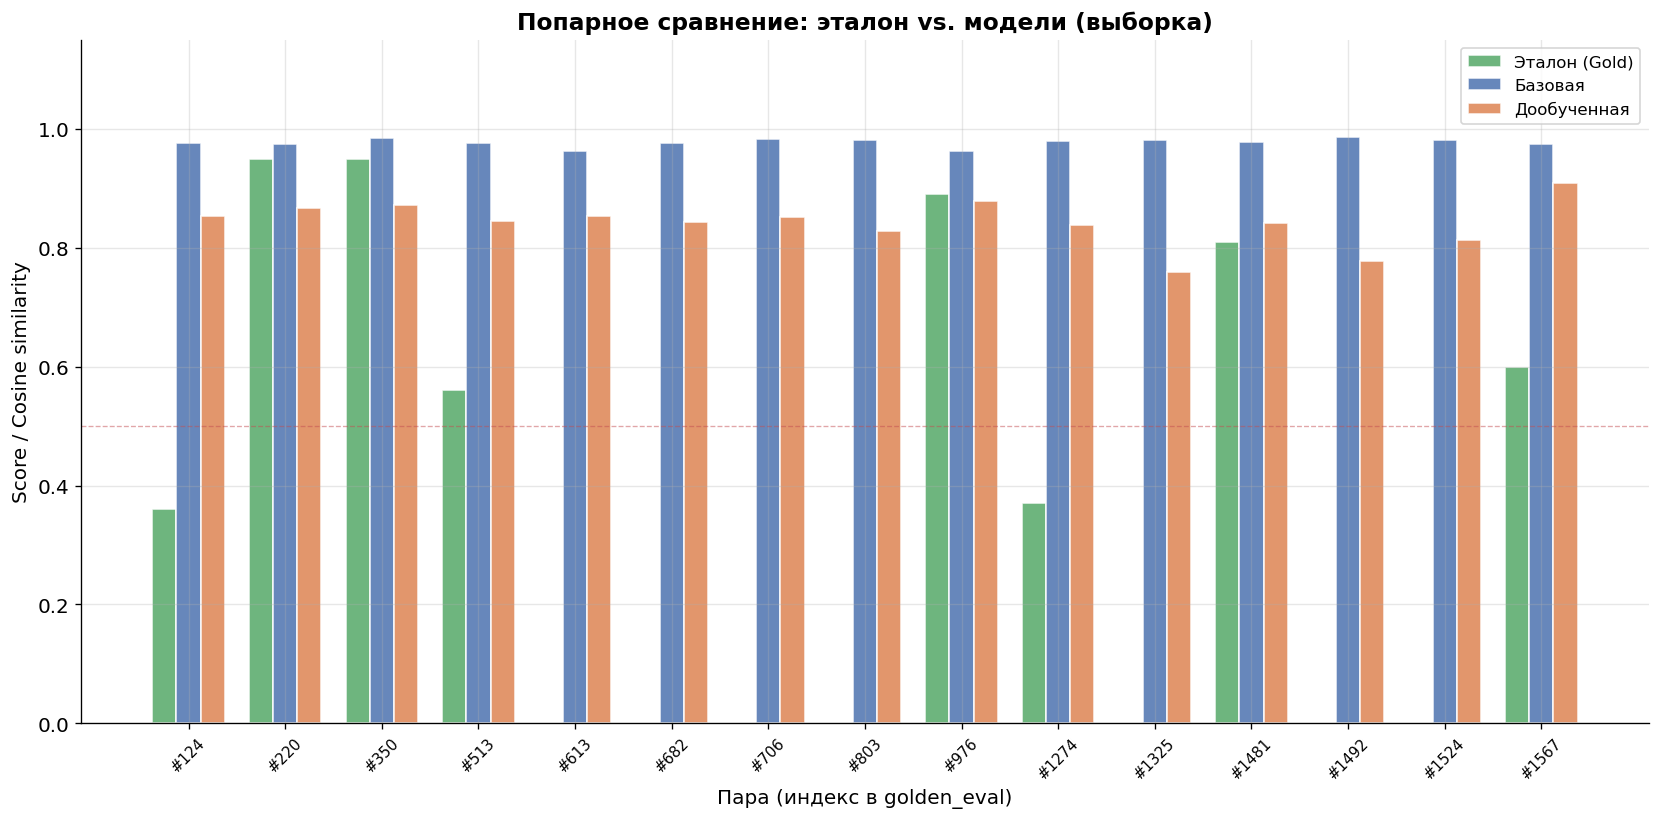

In [32]:
np.random.seed(42)
sample_idx = np.sort(np.random.choice(len(gold_scores), size=15, replace=False))

fig, ax = plt.subplots(figsize=(14, 7))

pair_indices = np.arange(len(sample_idx))
width = 0.25

ax.bar(pair_indices - width, gold_scores[sample_idx], width, label='Эталон (Gold)',
       color=COLORS['ideal'], alpha=0.85, edgecolor='white')
ax.bar(pair_indices, base_scores[sample_idx], width, label='Базовая',
       color=COLORS['base'], alpha=0.85, edgecolor='white')
ax.bar(pair_indices + width, finetuned_scores[sample_idx], width, label='Дообученная',
       color=COLORS['finetuned'], alpha=0.85, edgecolor='white')

ax.set_xlabel('Пара (индекс в golden_eval)')
ax.set_ylabel('Score / Cosine similarity')
ax.set_title('Попарное сравнение: эталон vs. модели (выборка)', fontweight='bold')
ax.set_xticks(pair_indices)
ax.set_xticklabels([f'#{i}' for i in sample_idx], rotation=45, fontsize=9)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.15)
ax.axhline(y=0.5, color=COLORS['threshold'], linestyle='--', linewidth=0.8, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

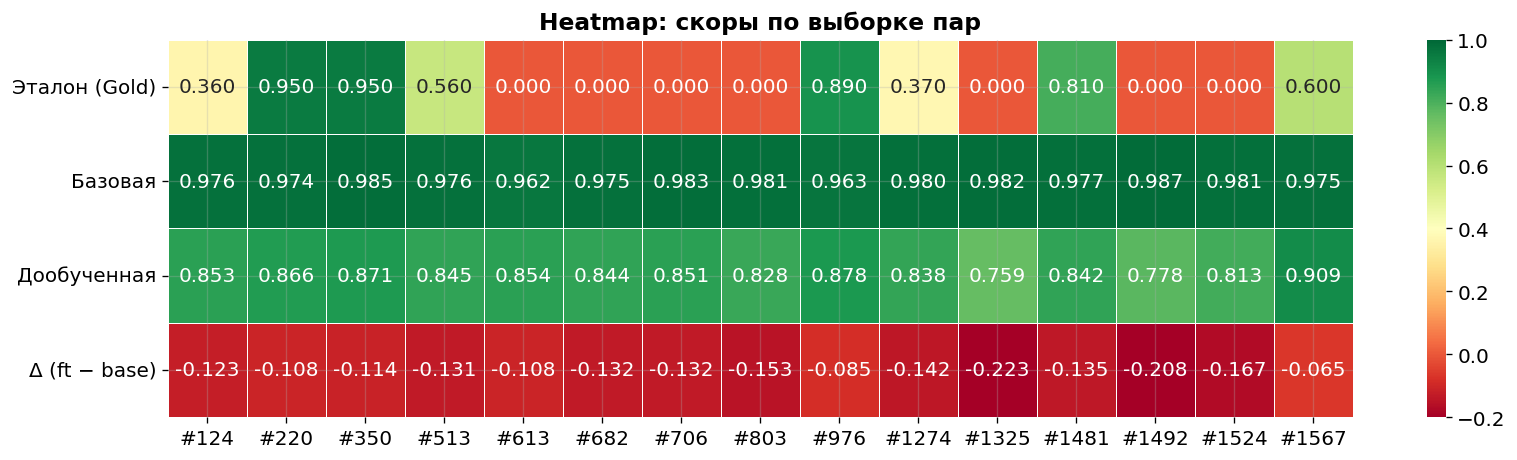

In [33]:
heatmap_data = np.vstack([
    gold_scores[sample_idx],
    base_scores[sample_idx],
    finetuned_scores[sample_idx],
    finetuned_scores[sample_idx] - base_scores[sample_idx],
])

row_labels = ['Эталон (Gold)', 'Базовая', 'Дообученная', 'Δ (ft − base)']
col_labels = [f'#{i}' for i in sample_idx]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=col_labels, yticklabels=row_labels,
            ax=ax, linewidths=0.5, vmin=-0.2, vmax=1.0)
ax.set_title('Heatmap: скоры по выборке пар', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 11. Сводная таблица результатов

In [34]:
summary_metrics = {
    'Spearman ρ': (float(corr_base['Spearman ρ']), float(corr_ft['Spearman ρ'])),
    'Pearson r': (float(corr_base['Pearson r']), float(corr_ft['Pearson r'])),
    'Kendall τ': (float(corr_base['Kendall τ']), float(corr_ft['Kendall τ'])),
    'NDCG@1': (rank_base['NDCG@1'], rank_ft['NDCG@1']),
    'NDCG@3': (rank_base['NDCG@3'], rank_ft['NDCG@3']),
    'NDCG@5': (rank_base['NDCG@5'], rank_ft['NDCG@5']),
    'NDCG@10': (rank_base['NDCG@10'], rank_ft['NDCG@10']),
    'MRR': (rank_base['MRR'], rank_ft['MRR']),
    'Hit@1': (rank_base['Hit@1'], rank_ft['Hit@1']),
    'Hit@3': (rank_base['Hit@3'], rank_ft['Hit@3']),
    'Hit@5': (rank_base['Hit@5'], rank_ft['Hit@5']),
}

summary_rows = []
for metric, (base_val, ft_val) in summary_metrics.items():
    delta = ft_val - base_val
    pct = (ft_val - base_val) / abs(base_val) * 100 if base_val != 0 else float('inf')

    summary_rows.append({
        'Метрика': metric,
        'Базовая': f'{base_val:.4f}',
        'Дообученная': f'{ft_val:.4f}',
        'Δ (абс.)': f'{delta:+.4f}',
        'Улучшение (%)': f'{pct:+.1f}%' if abs(pct) < 1e6 else 'N/A',
        'Результат': '✅ Лучше' if delta > 0.001 else ('⚠️ Хуже' if delta < -0.001 else '— Без изменений'),
    })

df_summary = pd.DataFrame(summary_rows).set_index('Метрика')
print('═' * 80)
print('  СВОДНАЯ ТАБЛИЦА: Базовая vs. Дообученная Bi-Encoder')
print('═' * 80)
df_summary

════════════════════════════════════════════════════════════════════════════════
  СВОДНАЯ ТАБЛИЦА: Базовая vs. Дообученная Bi-Encoder
════════════════════════════════════════════════════════════════════════════════


,Базовая,Дообученная,Δ (абс.),Улучшение (%),Результат
Метрика,,,,,
Spearman ρ,-0.0297,0.3934,+0.4231,+1424.6%,✅ Лучше
Pearson r,0.0329,0.3951,+0.3622,+1100.9%,✅ Лучше
Kendall τ,-0.0220,0.2830,+0.3050,+1386.4%,✅ Лучше
NDCG@1,0.0150,0.0274,+0.0124,+82.4%,✅ Лучше
NDCG@3,0.0277,0.0462,+0.0185,+66.8%,✅ Лучше
NDCG@5,0.0309,0.0561,+0.0252,+81.5%,✅ Лучше
NDCG@10,0.0358,0.0667,+0.0309,+86.3%,✅ Лучше
MRR,0.0351,0.0572,+0.0221,+63.0%,✅ Лучше
Hit@1,0.0155,0.0242,+0.0087,+56.2%,✅ Лучше


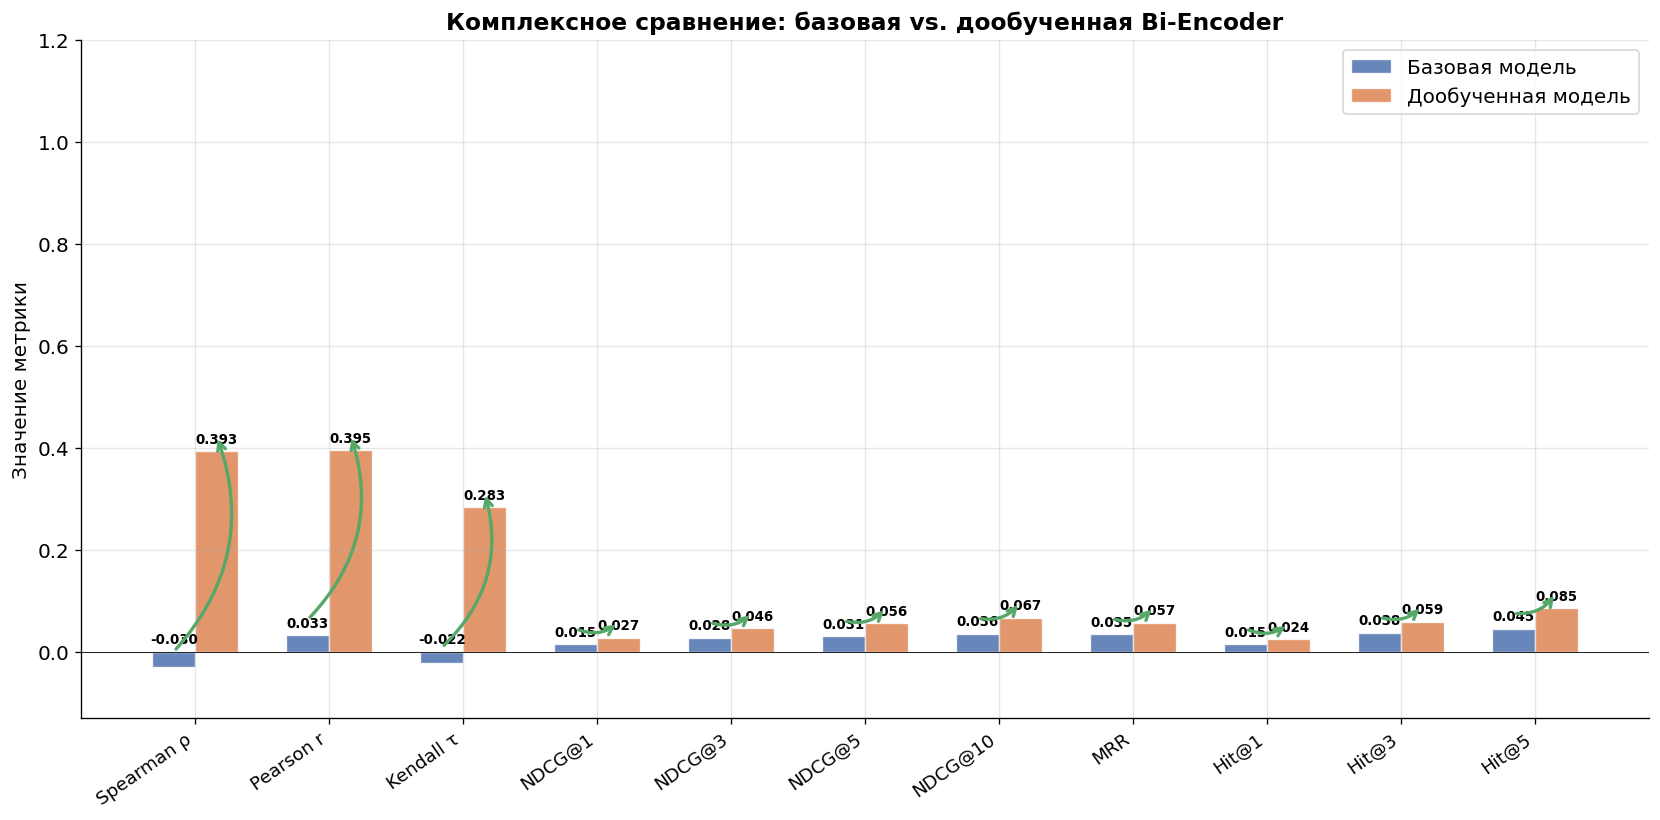

In [35]:
fig, ax = plt.subplots(figsize=(14, 7))

metric_names = list(summary_metrics.keys())
base_vals = [summary_metrics[m][0] for m in metric_names]
ft_vals = [summary_metrics[m][1] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.32

bars1 = ax.bar(x - width/2, base_vals, width, label='Базовая модель',
               color=COLORS['base'], alpha=0.85, edgecolor='white', linewidth=0.8)
bars2 = ax.bar(x + width/2, ft_vals, width, label='Дообученная модель',
               color=COLORS['finetuned'], alpha=0.85, edgecolor='white', linewidth=0.8)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if abs(h) > 0.005:
        ax.text(bar.get_x() + bar.get_width()/2., max(h, 0) + 0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, metric in enumerate(metric_names):
    b, f_ = summary_metrics[metric]
    delta = f_ - b
    if delta > 0.001:
        ax.annotate('', xy=(i + width/2, f_ + 0.03), xytext=(i - width/2, b + 0.03),
                    arrowprops=dict(arrowstyle='->', color=COLORS['ideal'],
                                   lw=2, connectionstyle='arc3,rad=.3'))

ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_title('Комплексное сравнение: базовая vs. дообученная Bi-Encoder', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=35, ha='right', fontsize=11)
ax.legend(fontsize=12, loc='upper right')
ax.set_ylim(min(min(base_vals), 0) - 0.1, max(max(ft_vals), 1.0) + 0.2)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

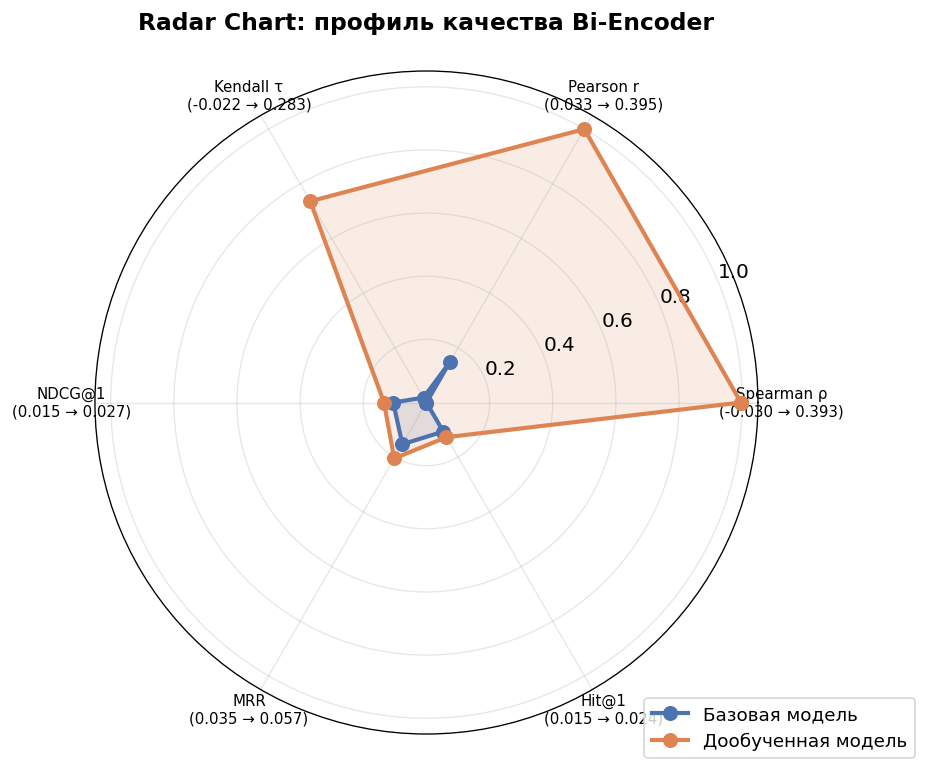

In [36]:
radar_metrics = ['Spearman ρ', 'Pearson r', 'Kendall τ', 'NDCG@1', 'MRR', 'Hit@1']
base_radar = [summary_metrics[m][0] for m in radar_metrics]
ft_radar = [summary_metrics[m][1] for m in radar_metrics]

# Нормализация: если есть отрицательные значения, сдвигаем в [0, 1]
all_vals = base_radar + ft_radar
min_val = min(0, min(all_vals))
max_val = max(all_vals)
if min_val < 0:
    base_radar_norm = [(v - min_val) / (max_val - min_val) for v in base_radar]
    ft_radar_norm = [(v - min_val) / (max_val - min_val) for v in ft_radar]
else:
    base_radar_norm = base_radar
    ft_radar_norm = ft_radar

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
base_radar_norm += base_radar_norm[:1]
ft_radar_norm += ft_radar_norm[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, base_radar_norm, 'o-', linewidth=2.5, label='Базовая модель',
        color=COLORS['base'], markersize=8)
ax.fill(angles, base_radar_norm, alpha=0.15, color=COLORS['base'])

ax.plot(angles, ft_radar_norm, 'o-', linewidth=2.5, label='Дообученная модель',
        color=COLORS['finetuned'], markersize=8)
ax.fill(angles, ft_radar_norm, alpha=0.15, color=COLORS['finetuned'])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f'{m}\n({base_radar[i]:.3f} → {ft_radar[i]:.3f})'
                     for i, m in enumerate(radar_metrics)], fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_title('Radar Chart: профиль качества Bi-Encoder', fontweight='bold',
             fontsize=14, pad=25)
ax.legend(loc='lower right', fontsize=11, bbox_to_anchor=(1.25, -0.05))

plt.tight_layout()
plt.show()

---
## 12. Выводы

### Основные результаты

Бенчмарк проведён на **golden_eval** (1 598 пар), не использовавшихся при обучении.

| Аспект | Базовая модель | Дообученная модель | Комментарий |
|--------|---------------|-------------------|-------------|
| **Spearman ρ** | (см. таблицу выше) | (см. таблицу выше) | Основная метрика STS |
| **Ranking (NDCG, MRR)** | — | — | Ранжирование среди 1 598 кандидатов |

### Контекст: Bi-Encoder vs. Cross-Encoder

| Модель | Spearman ρ (golden) | Скорость | Применение |
|--------|--------------------:|----------|------------|
| Cross-Encoder (fine-tuned) | **0.7280** | O(n) за запрос | Re-ranking |
| Bi-Encoder (fine-tuned) | см. выше | O(1) через FAISS | Retrieval |

Bi-Encoder *ожидаемо* уступает Cross-Encoder по точности, но выигрывает по скорости. В production-пайплайне они работают вместе: Bi-Encoder делает быструю выборку кандидатов, Cross-Encoder переранжирует топ-k.